# Wine Quality Prediction

**OASIS INFOBYTE — Data Analytics Internship**

Name: Prince Kumar  
Track: Data Analytics  
Level: Level 2  
Task: Task 2 — Wine Quality Prediction





## Objective

The objective of this project is to predict wine quality based on its physicochemical properties using machine learning classification models.

The project includes data exploration, class imbalance analysis, feature engineering, model training, evaluation, and comparison.


## Machine Learning Models
The following classification models will be trained and compared:

- Random Forest Classifier
- Stochastic Gradient Descent (SGD) Classifier
- Support Vector Classifier (SVC)

## Dataset

Dataset: Wine Quality — Red Wine  
Source: UCI Machine Learning Repository

## Tools & Technologies

- Python
- Pandas
- NumPy
- Scikit-learn
- Matplotlib
- Seaborn
- Google Colab

In [1]:
#library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import SGDClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [3]:
import pandas as pd
from google.colab import files

# Upload dataset
uploaded = files.upload()

# Load dataset
df = pd.read_csv('winequality-red.csv', sep=';')

print("Dataset loaded successfully!")

Saving winequality-red.csv to winequality-red.csv
Dataset loaded successfully!


In [4]:
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [5]:
# Check the number of rows and columns
df.shape

(1599, 12)

In [6]:
# Check column names
df.columns

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality'],
      dtype='object')

In [7]:
# Check for missing values
df.isnull().sum()

,0
fixed acidity,0
volatile acidity,0
citric acid,0
residual sugar,0
chlorides,0
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,0
sulphates,0


In [8]:
# Check  distribution of wine quality scores
df['quality'].value_counts().sort_index()

,count
quality,
3,10
4,53
5,681
6,638
7,199
8,18


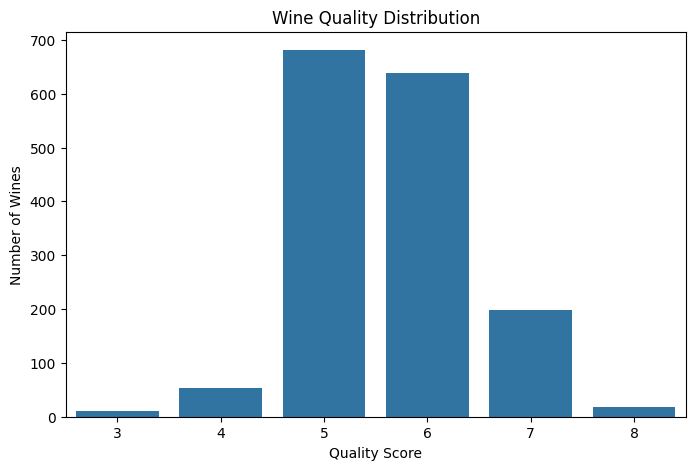

In [9]:
plt.figure(figsize=(8, 5))

sns.countplot(data=df, x='quality')

plt.title('Wine Quality Distribution')
plt.xlabel('Quality Score')
plt.ylabel('Number of Wines')

plt.show()

In [10]:
# Check the number of samples in each quality class
quality_counts = df['quality'].value_counts().sort_index()

print(quality_counts)

quality
3     10
4     53
5    681
6    638
7    199
8     18
Name: count, dtype: int64


In [11]:
# Calculate percentage of each quality score
quality_percentage = df['quality'].value_counts(normalize=True).sort_index() * 100

print(quality_percentage.round(2))

quality
3     0.63
4     3.31
5    42.59
6    39.90
7    12.45
8     1.13
Name: proportion, dtype: float64


## Class Imbalance

The distribution of wine quality scores is not balanced. Some quality scores have many more samples than others, while higher and lower quality scores are less represented.

Class imbalance can affect machine learning models because the model may learn the majority classes better and perform poorly on underrepresented classes.

To address this issue, the quality scores will be grouped into three categories: Low, Medium, and High. Stratified train-test splitting will also be used to preserve the class distribution.

In [12]:
# Convert quality scores into three categories

def quality_category(quality):
    if quality <= 4:
        return 'Low'
    elif quality <= 6:
        return 'Medium'
    else:
        return 'High'

df['quality_category'] = df['quality'].apply(quality_category)

df[['quality', 'quality_category']].head(10)

,quality,quality_category
0,5,Medium
1,5,Medium
2,5,Medium
3,6,Medium
4,5,Medium
5,5,Medium
6,5,Medium
7,7,High
8,7,High
9,5,Medium


In [13]:
# Check the new class distribution
df['quality_category'].value_counts()


,count
quality_category,
Medium,1319
High,217
Low,63


## Feature Engineering

The original wine quality scores range from 3 to 8. For classification, the scores are grouped into three categories:

- Low: Quality 3–4
- Medium: Quality 5–6
- High: Quality 7–8

A three-class approach is selected because it provides a meaningful distinction between low, medium, and high-quality wines while keeping the classification problem manageable.

In [14]:
# Separate features and target
X = df.drop(columns=['quality', 'quality_category'])
y = df['quality_category']

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (1599, 11)
Target shape: (1599,)


In [15]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (1279, 11)
Testing data: (320, 11)


In [16]:
# Scale the features
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed successfully!")

Feature scaling completed successfully!


In [17]:
# Train Random Forest Classifier
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [18]:
# Make predictions
y_pred_rf = rf_model.predict(X_test)

print("Random Forest predictions completed!")

Random Forest predictions completed!


In [19]:
# Calculate accuracy
rf_accuracy = accuracy_score(y_test, y_pred_rf)

print("Random Forest Accuracy:", round(rf_accuracy, 4))

Random Forest Accuracy: 0.8656


In [20]:
# Classification report
print("Random Forest Classification Report:\n")
print(classification_report(y_test, y_pred_rf))

Random Forest Classification Report:

              precision    recall  f1-score   support

        High       0.71      0.51      0.59        43
         Low       0.00      0.00      0.00        13
      Medium       0.88      0.97      0.92       264

    accuracy                           0.87       320
   macro avg       0.53      0.49      0.51       320
weighted avg       0.82      0.87      0.84       320



/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


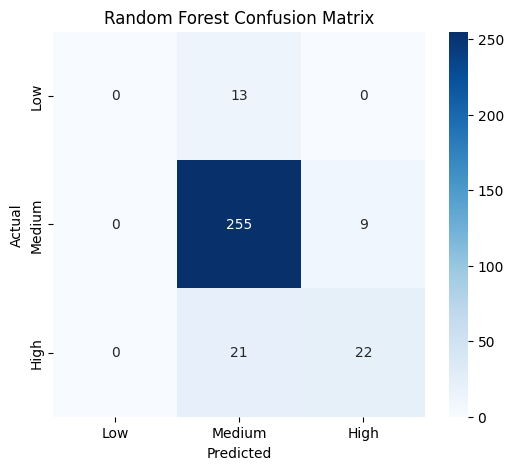

In [21]:
# Confusion matrix with fixed class order
labels = ['Low', 'Medium', 'High']

cm_rf = confusion_matrix(y_test, y_pred_rf, labels=labels)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_rf,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=labels,
    yticklabels=labels
)

plt.title('Random Forest Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [22]:
# Train SGD Classifier
sgd_model = SGDClassifier(
    random_state=42
)

sgd_model.fit(X_train_scaled, y_train)

print("SGD Classifier trained successfully!")

SGD Classifier trained successfully!


In [23]:
# Make predictions
y_pred_sgd = sgd_model.predict(X_test_scaled)

# Calculate accuracy
sgd_accuracy = accuracy_score(y_test, y_pred_sgd)

print("SGD Accuracy:", round(sgd_accuracy, 4))

SGD Accuracy: 0.825


In [24]:
# Classification report
print("SGD Classification Report:\n")
print(classification_report(y_test, y_pred_sgd))

SGD Classification Report:

              precision    recall  f1-score   support

        High       0.52      0.33      0.40        43
         Low       0.00      0.00      0.00        13
      Medium       0.86      0.95      0.90       264

    accuracy                           0.82       320
   macro avg       0.46      0.42      0.43       320
weighted avg       0.78      0.82      0.80       320



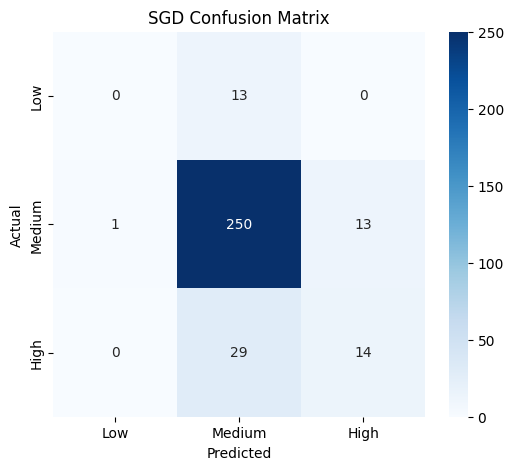

In [25]:
# Confusion matrix
labels = ['Low', 'Medium', 'High']

cm_sgd = confusion_matrix(y_test, y_pred_sgd, labels=labels)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_sgd,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=labels,
    yticklabels=labels
)

plt.title('SGD Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [26]:
# Train Support Vector Classifier
svc_model = SVC()

svc_model.fit(X_train_scaled, y_train)

print("SVC model trained successfully!")

SVC model trained successfully!


In [27]:
# Make predictions
y_pred_svc = svc_model.predict(X_test_scaled)

# Calculate accuracy
svc_accuracy = accuracy_score(y_test, y_pred_svc)

print("SVC Accuracy:", round(svc_accuracy, 4))


SVC Accuracy: 0.8438


In [28]:
# Classification report
print("SVC Classification Report:\n")
print(classification_report(y_test, y_pred_svc))

SVC Classification Report:

              precision    recall  f1-score   support

        High       0.64      0.33      0.43        43
         Low       0.00      0.00      0.00        13
      Medium       0.86      0.97      0.91       264

    accuracy                           0.84       320
   macro avg       0.50      0.43      0.45       320
weighted avg       0.79      0.84      0.81       320



/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


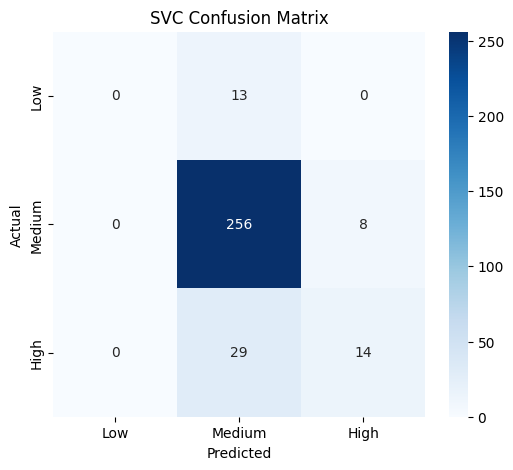

In [29]:
# Confusion matrix
labels = ['Low', 'Medium', 'High']

cm_svc = confusion_matrix(y_test, y_pred_svc, labels=labels)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_svc,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=labels,
    yticklabels=labels
)

plt.title('SVC Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

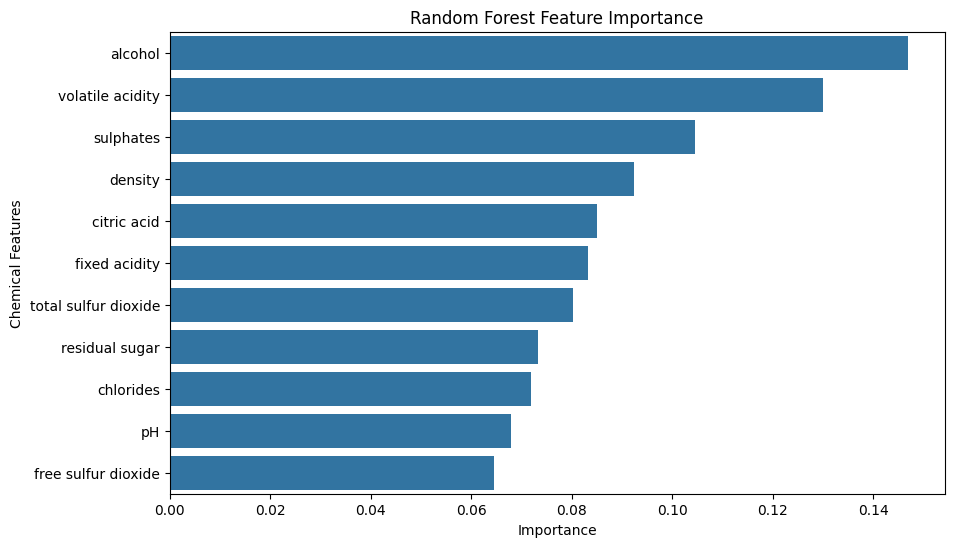

In [30]:
#feature importance chart
feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=feature_importance.values,
    y=feature_importance.index
)

plt.title('Random Forest Feature Importance')
plt.xlabel('Importance')
plt.ylabel('Chemical Features')

plt.show()

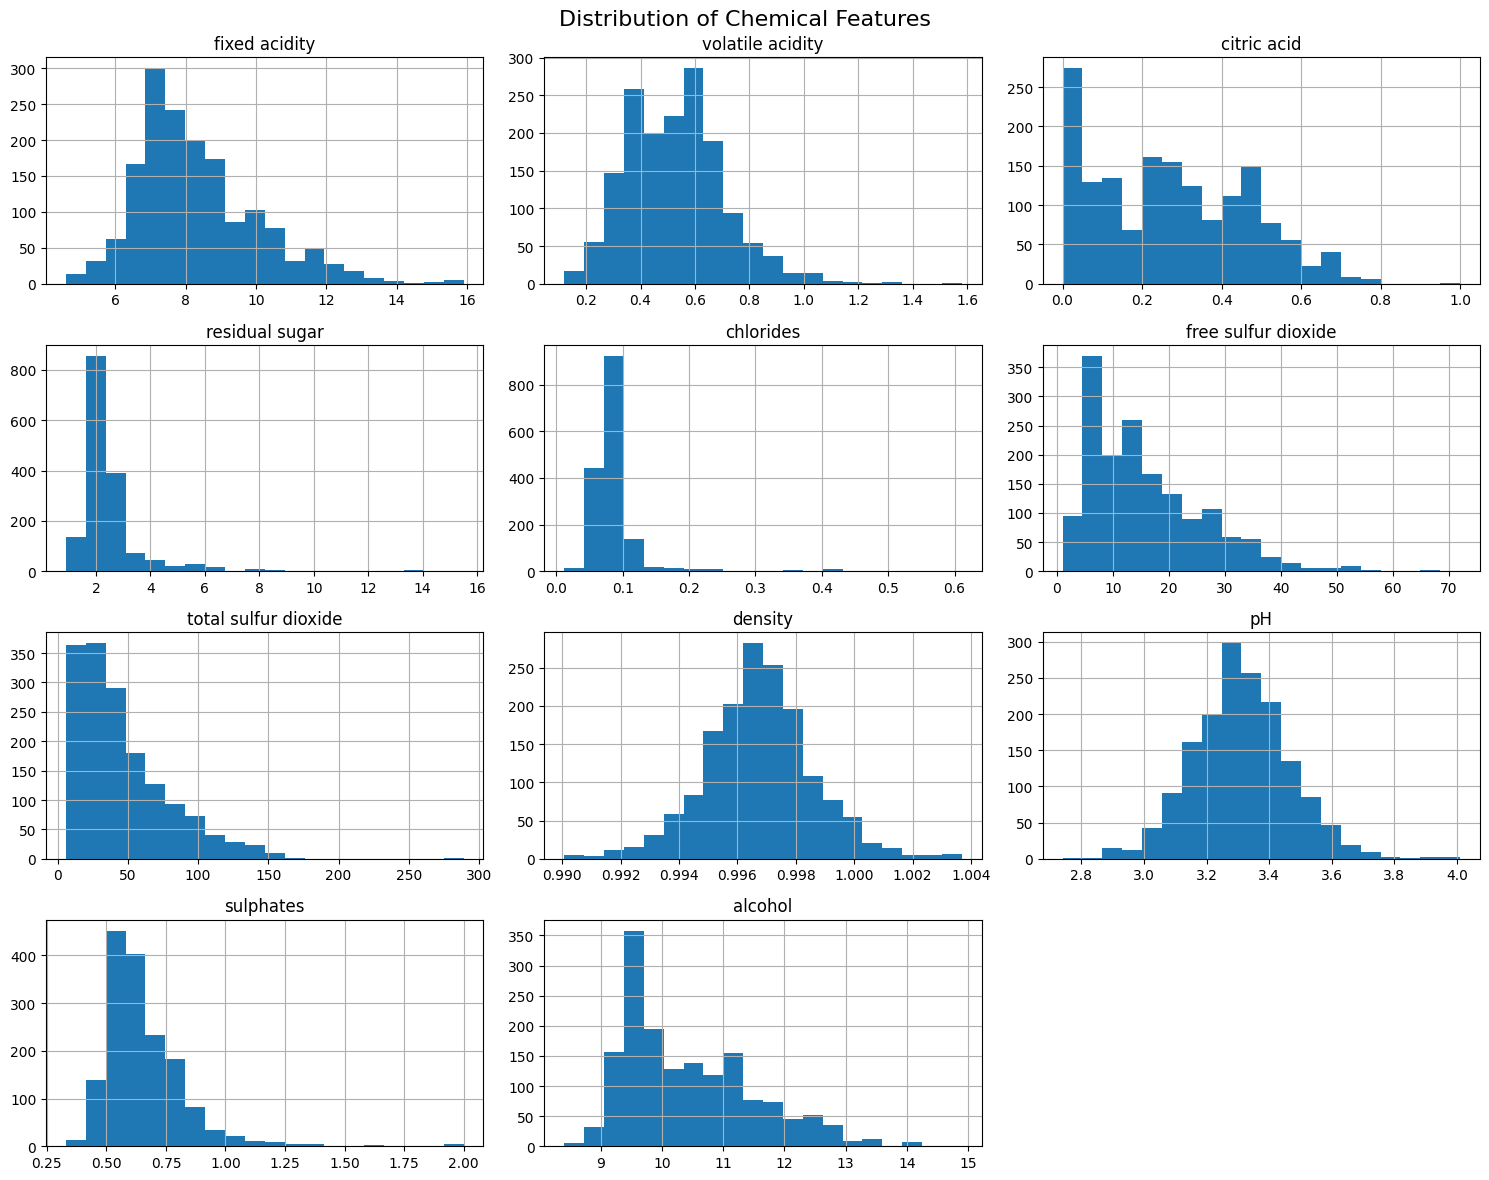

In [31]:
# Distribution plots for all chemical features

chemical_features = X.columns

df[chemical_features].hist(
    figsize=(15, 12),
    bins=20
)

plt.suptitle('Distribution of Chemical Features', fontsize=16)
plt.tight_layout()

plt.show()

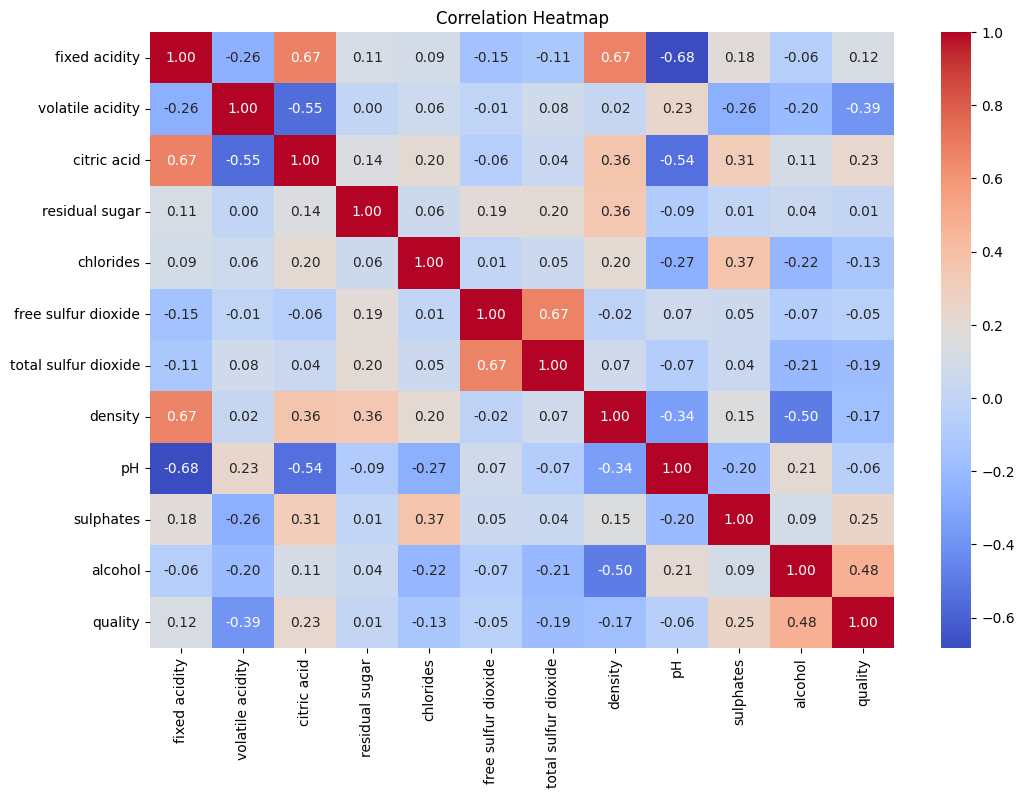

In [32]:
# Correlation heatmap

correlation_matrix = df.corr(numeric_only=True)

plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap')
plt.show()

In [34]:
from sklearn.metrics import precision_score, recall_score, f1_score

In [35]:
# Model comparison

comparison = pd.DataFrame({
    'Model': ['Random Forest', 'SGD', 'SVC'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_sgd),
        accuracy_score(y_test, y_pred_svc)
    ],
    'Precision': [
        precision_score(y_test, y_pred_rf, average='weighted'),
        precision_score(y_test, y_pred_sgd, average='weighted'),
        precision_score(y_test, y_pred_svc, average='weighted')
    ],
    'Recall': [
        recall_score(y_test, y_pred_rf, average='weighted'),
        recall_score(y_test, y_pred_sgd, average='weighted'),
        recall_score(y_test, y_pred_svc, average='weighted')
    ],
    'F1-Score': [
        f1_score(y_test, y_pred_rf, average='weighted'),
        f1_score(y_test, y_pred_sgd, average='weighted'),
        f1_score(y_test, y_pred_svc, average='weighted')
    ]
})

comparison.round(4)

/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


,Model,Accuracy,Precision,Recall,F1-Score
0,Random Forest,0.8656,0.8233,0.8656,0.8407
1,SGD,0.8250,0.7760,0.8250,0.7957
2,SVC,0.8438,0.7942,0.8438,0.8095


## Conclusion

Three classification models were trained and compared to predict wine quality categories:

- Random Forest Classifier
- SGD Classifier
- Support Vector Classifier (SVC)

Based on the evaluation results, Random Forest achieved the best overall performance with an accuracy of **86.56%** and an F1-score of **84.07%**.

SVC achieved an accuracy of **84.38%**, while SGD achieved an accuracy of **82.50%**.

Therefore, **Random Forest is the most suitable model for deployment** among the three tested models because it provided the highest accuracy and F1-score.

However, the wine quality classes are imbalanced, with the Medium category having significantly more observations than the Low and High categories. Therefore, further improvements such as class balancing, hyperparameter tuning, and additional evaluation on unseen data could improve the model's performance, especially for the minority classes.

Overall, the project demonstrates how machine learning classification models can be used to predict wine quality categories from physicochemical properties.